# E-Commerce Order Status Classification Using AI

## DecodeLabs Artificial Intelligence Internship — Project 2

### Data Classification Using AI

This project demonstrates a supervised machine learning classification
workflow using the e-commerce dataset provided for the internship.

The objective is to train a machine learning model to classify e-commerce
orders into their respective order-status categories.


In [60]:
# DecodeLabs AI Internship - Project 2
# Data Classification Using AI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [61]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 1. Project Objective

The objective of this project is to build a basic supervised machine learning classification model using the provided e-commerce dataset.

The project focuses on:

- Understanding and preparing the dataset
- Selecting relevant input features
- Identifying the target variable
- Splitting the data into training and testing sets
- Applying a classification algorithm
- Training the model using labeled data
- Making predictions on unseen test data
- Evaluating the model using classification metrics

In [62]:
# ============================================================
# STEP 3: UNDERSTAND THE DATASET
# ============================================================

print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

========== DATASET SHAPE ==========
(1200, 14)

========== COLUMN NAMES ==========
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

========== DATA TYPES ==========
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

========== MISSING VALUES ==========
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress  

## 2. Dataset Exploration

Before building the classification model, the dataset is examined to understand its structure, attributes, data types, missing values, and duplicate records.

This step helps identify the preprocessing operations required before training the machine learning model.

In [63]:
# ============================================================
# STEP 4: VIEW THE DATA
# ============================================================

display(df.head(10))

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


## 3. Target Variable Distribution

The target variable for this classification problem is `OrderStatus`.

The distribution of the five order-status categories is examined to understand the number of observations belonging to each class.

In [64]:
# ============================================================
# STEP 5: CHECK ORDER STATUS
# ============================================================

print("Order Status Distribution:")
print(df["OrderStatus"].value_counts())

Order Status Distribution:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


## 4. Order Status Visualization

The distribution of order-status categories is visualized using a bar chart to provide a clear view of the class distribution.

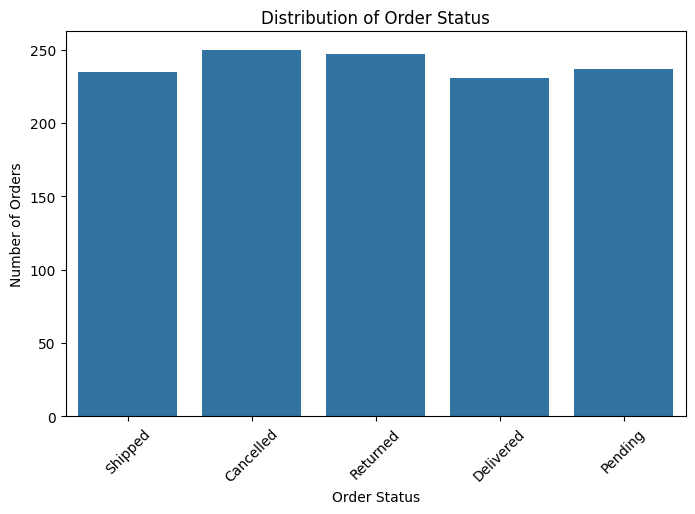

In [65]:
# ============================================================
# STEP 6: VISUALIZE ORDER STATUS
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="OrderStatus")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

## 5. Feature Selection

The target variable is separated from the input features.

`OrderStatus` is selected as the target variable because it represents the class that the model is required to predict.

Identifier and direct identification fields such as `OrderID`, `CustomerID`, `TrackingNumber`, and `ShippingAddress` are excluded from the model inputs.

In [66]:
# ============================================================
# STEP 7: SELECT FEATURES AND TARGET
# ============================================================

# Target variable
y = df["OrderStatus"]

# Remove columns that are identifiers or unsuitable as
# direct prediction features
X = df.drop(
    columns=[
        "OrderStatus",
        "OrderID",
        "CustomerID",
        "TrackingNumber",
        "ShippingAddress"
    ]
)

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
['Date', 'Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Target (y):
OrderStatus

X shape: (1200, 9)
y shape: (1200,)


## 6. Data Preprocessing

The raw dataset contains both numerical and categorical information.

The `Date` column is transformed into useful numerical features such as year, month, day, and day of the week.

This preprocessing prepares the dataset for use with the machine learning model.

In [67]:
# ============================================================
# STEP 8: PROCESS THE DATE COLUMN
# ============================================================

# Make a copy so the original dataset stays unchanged
data = X.copy()

# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Extract useful date information
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["DayOfWeek"] = data["Date"].dt.dayofweek

# Remove the original Date column
data.drop("Date", axis=1, inplace=True)

print("Features after processing Date:")
print(data.columns.tolist())

display(data.head())

Features after processing Date:
['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year', 'Month', 'Day', 'DayOfWeek']


,Product,Quantity,UnitPrice,PaymentMethod,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayOfWeek
0,Monitor,5,570.62,Debit Card,7,SAVE10,Instagram,2853.10,2023,1,4,2
1,Phone,2,151.35,Online,3,SAVE10,Referral,302.70,2024,8,23,4
2,Tablet,5,550.68,Credit Card,8,FREESHIP,Email,2753.40,2024,2,27,1
3,Chair,1,273.19,Debit Card,5,SAVE10,Facebook,273.19,2023,10,15,6
4,Printer,4,626.01,Online,8,SAVE10,Email,2504.04,2025,5,8,3


## 7. Handling Missing Values

The `CouponCode` column contains missing values.

Missing coupon values are replaced with `No Coupon` so that the information is retained while eliminating missing values from the categorical feature.

In [68]:
# ============================================================
# STEP 9: HANDLE MISSING VALUES
# ============================================================

data["CouponCode"] = data["CouponCode"].fillna("No Coupon")

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Product           0
Quantity          0
UnitPrice         0
PaymentMethod     0
ItemsInCart       0
CouponCode        0
ReferralSource    0
TotalPrice        0
Year              0
Month             0
Day               0
DayOfWeek         0
dtype: int64


## 8. Numerical and Categorical Features

The processed dataset is divided into numerical and categorical feature groups.

Numerical features will be scaled using `StandardScaler`, while categorical features will be converted into numerical representations using `OneHotEncoder`.

In [69]:
# ============================================================
# STEP 10: CHECK FEATURE TYPES
# ============================================================

numerical_features = data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Features:
['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']


## 9. Supervised Learning and Train-Test Split

This project uses supervised learning because the training data contains both input features and their corresponding known `OrderStatus` labels.

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to learn patterns from labeled examples, while the testing data is kept separate for evaluating the model on unseen data.

Stratified splitting is used to maintain the distribution of the order-status classes across the training and testing datasets.

In [70]:
# ============================================================
# STEP 11: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    data,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (960, 12)
y_train: (960,)

Testing data:
X_test: (240, 12)
y_test: (240,)


## 10. Feature Preprocessing Pipeline

Numerical features are standardized using `StandardScaler`.

Categorical features are transformed into numerical representations using `OneHotEncoder`.

This preprocessing is required because KNN operates using distances between observations.

In [71]:
# ============================================================
# STEP 12: PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 11. Classification Algorithm: K-Nearest Neighbors

K-Nearest Neighbors (KNN) is used as the classification algorithm.

KNN classifies a new observation by examining nearby training examples and assigning a class based on the neighboring observations.

The initial model uses `K = 5`. Different K values will later be tested to examine their effect on model performance.

In [72]:
# ============================================================
# STEP 13: CREATE KNN CLASSIFICATION MODEL
# ============================================================

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

print("KNN model created successfully!")
print("Number of neighbors (K): 5")

KNN model created successfully!
Number of neighbors (K): 5


## 12. Model Training

The KNN classifier is trained using the training dataset.

The model learns from the labeled training examples while the test data remains separate for later evaluation.

In [73]:
# ============================================================
# STEP 14: TRAIN THE MODEL
# ============================================================

print("Training KNN model...")

knn_model.fit(X_train, y_train)

print("Model training completed successfully!")

Training KNN model...
Model training completed successfully!


## 13. Model Prediction

After training, the KNN model is used to predict the `OrderStatus` of the unseen test observations.

The predicted labels are then compared with the actual labels from the test dataset.

In [74]:
# ============================================================
# STEP 15: MAKE PREDICTIONS
# ============================================================

y_pred = knn_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
['Returned' 'Delivered' 'Cancelled' 'Cancelled' 'Cancelled' 'Pending'
 'Cancelled' 'Pending' 'Shipped' 'Returned' 'Delivered' 'Delivered'
 'Shipped' 'Pending' 'Shipped' 'Delivered' 'Cancelled' 'Shipped' 'Pending'
 'Pending']


## 14. Initial Model Evaluation

Accuracy measures the proportion of test observations that were classified correctly.

It provides an initial indication of model performance, while additional metrics are used to evaluate performance across individual classes.

In [75]:
# ============================================================
# STEP 16: CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("KNN Model Accuracy:")
print(round(accuracy * 100, 2), "%")

KNN Model Accuracy:
17.5 %


## 15. Confusion Matrix

A confusion matrix provides a detailed view of the actual and predicted order-status classes.

It helps identify which classes are correctly classified and which classes are frequently confused with one another.

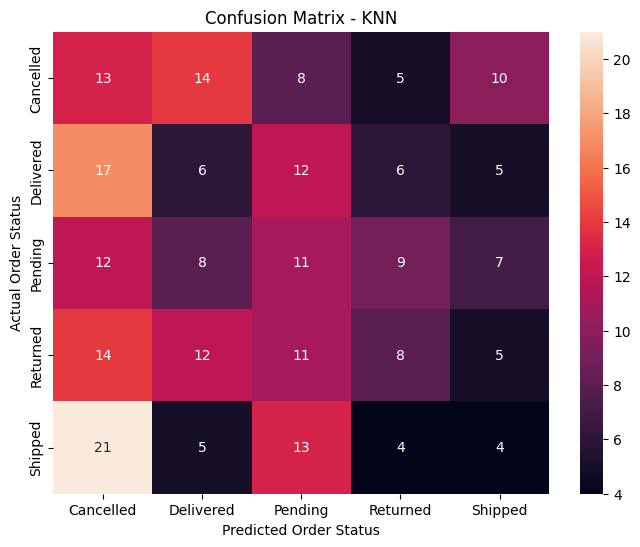

In [76]:
# ============================================================
# STEP 17: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Order Status")
plt.ylabel("Actual Order Status")

plt.show()

## 16. Experimenting with Different K Values

The performance of K-Nearest Neighbors depends on the number of neighbors selected.

Different K values are tested to examine how the choice of K affects the classification accuracy.

The results are visualized using a K value versus accuracy plot.

K =  1 | Accuracy = 19.17%
K =  2 | Accuracy = 20.42%
K =  3 | Accuracy = 22.50%
K =  4 | Accuracy = 17.08%
K =  5 | Accuracy = 17.50%
K =  6 | Accuracy = 17.92%
K =  7 | Accuracy = 19.17%
K =  8 | Accuracy = 18.33%
K =  9 | Accuracy = 17.50%
K = 10 | Accuracy = 18.33%
K = 11 | Accuracy = 16.67%
K = 12 | Accuracy = 17.08%
K = 13 | Accuracy = 16.67%
K = 14 | Accuracy = 16.67%
K = 15 | Accuracy = 18.75%


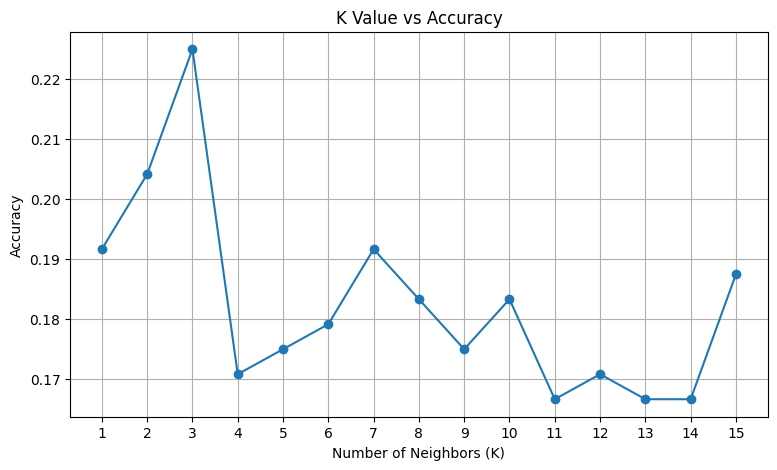

In [77]:
# ============================================================
# STEP 18: TEST AND VISUALIZE DIFFERENT K VALUES
# ============================================================

k_values = range(1, 16)
k_accuracies = []

for k in k_values:

    knn_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                KNeighborsClassifier(n_neighbors=k)
            )
        ]
    )

    knn_pipeline.fit(X_train, y_train)

    predictions = knn_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    k_accuracies.append(accuracy)

for k, accuracy in zip(k_values, k_accuracies):
    print(f"K = {k:2d} | Accuracy = {accuracy * 100:.2f}%")

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    k_accuracies,
    marker="o"
)

plt.title("K Value vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

## 17. Refining the Feature Preprocessing

The date-derived features are included in the numerical feature list so that all processed numerical features are correctly incorporated into the machine learning preprocessing pipeline.

The numerical and categorical feature lists are updated before rebuilding the preprocessing pipeline.

In [78]:
# ============================================================
# STEP 19: UPDATE FEATURE LISTS
# ============================================================

numerical_features = data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Features:
['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']


## 18. Updated Preprocessing Pipeline

The preprocessing pipeline is recreated using the updated numerical and categorical feature lists.

This ensures that all relevant processed features are correctly transformed before being passed to the KNN classifier.

In [79]:
# ============================================================
# STEP 20: RECREATE PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline updated successfully!")

Preprocessing pipeline updated successfully!


## 19. Updated Train-Test Split

The dataset is split again into training and testing sets using the updated feature configuration.

An 80:20 train-test ratio and stratified sampling are maintained to preserve the distribution of the five order-status classes.

In [80]:
# ============================================================
# STEP 21: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    data,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 960
Testing samples: 240


## 20. Re-evaluating Different K Values

The KNN experiment is repeated using the updated preprocessing configuration.

K values from 1 to 15 are evaluated, and their corresponding test accuracies are compared to confirm the selected K value.

In [81]:
# ============================================================
# STEP 22: TEST DIFFERENT K VALUES AGAIN
# ============================================================

k_values = range(1, 16)
k_accuracies = []

for k in k_values:

    knn_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                KNeighborsClassifier(n_neighbors=k)
            )
        ]
    )

    knn_pipeline.fit(X_train, y_train)

    predictions = knn_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    k_accuracies.append(accuracy)

for k, accuracy in zip(k_values, k_accuracies):
    print(f"K = {k:2d} | Accuracy = {accuracy * 100:.2f}%")

K =  1 | Accuracy = 19.17%
K =  2 | Accuracy = 20.42%
K =  3 | Accuracy = 22.50%
K =  4 | Accuracy = 17.08%
K =  5 | Accuracy = 17.50%
K =  6 | Accuracy = 17.92%
K =  7 | Accuracy = 19.17%
K =  8 | Accuracy = 18.33%
K =  9 | Accuracy = 17.50%
K = 10 | Accuracy = 18.33%
K = 11 | Accuracy = 16.67%
K = 12 | Accuracy = 17.08%
K = 13 | Accuracy = 16.67%
K = 14 | Accuracy = 16.67%
K = 15 | Accuracy = 18.75%


## 21. Final KNN Model

The final KNN model is evaluated on the unseen test dataset using accuracy, weighted precision, weighted recall, and weighted F1 score.

These metrics provide an overall assessment of the final classification performance.

In [82]:
# ============================================================
# STEP 23: FINAL KNN MODEL
# ============================================================

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(n_neighbors=3)
        )
    ]
)

# Train final model
final_model.fit(X_train, y_train)

# Predict test data
final_predictions = final_model.predict(X_test)

print("Final KNN model trained successfully!")
print("Selected K:", 3)

Final KNN model trained successfully!
Selected K: 3


## 22. Final Model Performance

The final KNN model is evaluated on the unseen test dataset using accuracy, weighted precision, weighted recall, and weighted F1 score.

These metrics provide an overall assessment of the final classification performance.

In [83]:
# ============================================================
# STEP 24: FINAL MODEL EVALUATION
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_recall = recall_score(
    y_test,
    final_predictions,
    average="weighted"
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    average="weighted"
)

print("========================================")
print("FINAL MODEL PERFORMANCE")
print("========================================")

print(f"Algorithm : K-Nearest Neighbors (KNN)")
print(f"K value   : 3")
print(f"Accuracy  : {final_accuracy * 100:.2f}%")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

FINAL MODEL PERFORMANCE
Algorithm : K-Nearest Neighbors (KNN)
K value   : 3
Accuracy  : 22.50%
Precision : 0.2111
Recall    : 0.2250
F1 Score  : 0.2006


## 23. Final Confusion Matrix

The final confusion matrix shows the relationship between the actual and predicted order-status classes for the selected KNN model.

It provides a class-wise view of correct predictions and classification errors.

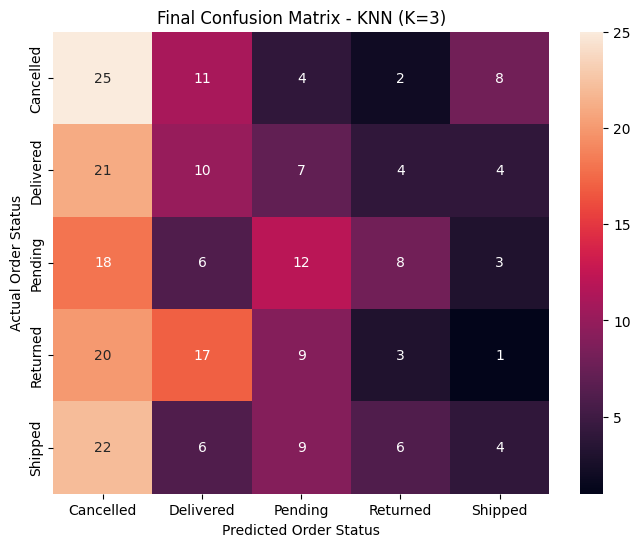

In [84]:
# ============================================================
# STEP 25: FINAL CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=final_model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.title("Final Confusion Matrix - KNN (K=3)")
plt.xlabel("Predicted Order Status")
plt.ylabel("Actual Order Status")

plt.show()

## 24. Final Classification Report

The classification report provides class-wise precision, recall, and F1 scores for the final KNN model.

These metrics help examine how the model performs for each individual order-status category.

In [85]:
# ============================================================
# STEP 26: CLASSIFICATION REPORT
# ============================================================

print("Classification Report:")
print(
    classification_report(
        y_test,
        final_predictions
    )
)

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.24      0.50      0.32        50
   Delivered       0.20      0.22      0.21        46
     Pending       0.29      0.26      0.27        47
    Returned       0.13      0.06      0.08        50
     Shipped       0.20      0.09      0.12        47

    accuracy                           0.23       240
   macro avg       0.21      0.22      0.20       240
weighted avg       0.21      0.23      0.20       240



# Results and Conclusion

The final KNN model with `K = 3` achieved an accuracy of **22.50%**, a weighted precision of **0.2111**, a weighted recall of **0.2250**, and a weighted F1 score of **0.2006** on the 240 test observations.

The relatively low performance indicates that the available features do not provide strong separation between the five order-status classes.

Overall, this project demonstrates the complete supervised learning workflow, including:

- Dataset exploration
- Feature selection
- Data preprocessing
- Handling missing values
- Train-test splitting
- Feature transformation
- KNN model training
- Prediction on unseen data
- Experimentation with different K values
- Model evaluation using multiple classification metrics
- Confusion matrix analysis

The project provides practical experience with the basic concepts of supervised classification using an e-commerce dataset.